[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/zhiyunli/cpsc5610-labs/blob/main/week7/lab_transfer_learning_pytorch.ipynb)

# Transfer Learning using PyTorch

Cats-vs-dogs classification on the Oxford-IIIT Pets dataset, using a pretrained MobileNetV2 backbone.

## MobileNet and MobileNetV2

**MobileNet** is a family of lightweight CNNs designed for mobile and embedded devices.  Key features:
- **Depthwise separable convolutions** (a depthwise conv per input channel + a 1x1 pointwise conv to mix channels), which dramatically reduces FLOPs and parameters.
- **MobileNetV2** adds **inverted residuals** (expand-conv-project, with skip connections at the bottleneck) and **linear bottlenecks** (no activation on the last 1x1 of each block).

In PyTorch, `torchvision.models.mobilenet_v2` exposes the model with ImageNet-pretrained weights.

## Top-1 and Top-5 Accuracy

- **Top-1**: the percentage of times the model's *single most confident* prediction equals the ground-truth label.
- **Top-5**: the percentage of times the ground-truth label appears anywhere in the model's top 5 predictions.

Top-5 is more forgiving and is the standard ImageNet metric for fine-grained classification tasks (1000 classes).

## Transfer-learning workflow

1. Load a model pretrained on ImageNet (here MobileNetV2).
2. **Freeze** the convolutional backbone so its weights are not updated.
3. **Replace the classification head** with one suited to our task (binary: cat vs dog).
4. Train only the new head on our small dataset.

In [1]:
import os
import tarfile
import urllib.request
from io import BytesIO
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchvision.models import mobilenet_v2, MobileNet_V2_Weights
from PIL import Image
import matplotlib.pyplot as plt
%matplotlib inline

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', device)

device: cuda


## Download and parse the Oxford-IIIT Pets dataset

The helpers below are inlined from the original `pets.py` so this notebook is self-contained.  They:
1. Download the images and annotations tarballs from the Oxford VGG group.
2. Extract them under `data/`.
3. Parse `trainval.txt` / `test.txt` into a `{image_name: 'cat'|'dog'}` dict, using the dataset's case convention — **filenames that start with an uppercase letter are cats; lowercase are dogs.**

In [2]:
# === inlined from pets.py ===
URLS = [
    'http://www.robots.ox.ac.uk/~vgg/data/pets/data/images.tar.gz',
    'http://www.robots.ox.ac.uk/~vgg/data/pets/data/annotations.tar.gz',
]

def download_and_extract(data_dir, download_dir):
    """Download the two tarballs into `download_dir` and extract under `data_dir`."""
    os.makedirs(data_dir, exist_ok=True)
    os.makedirs(download_dir, exist_ok=True)
    for url in URLS:
        target_file = url.split('/')[-1]
        target_path = os.path.join(download_dir, target_file)
        if not os.path.exists(target_path):
            print('Downloading', url)
            urllib.request.urlretrieve(url, target_path)
            with tarfile.open(target_path) as tf:
                tf.extractall(data_dir)
        else:
            print('Already downloaded', url)

def cats_vs_dogs_annotations(file_path):
    """Parse a Pets annotation file into {image_name.jpg: 'cat'|'dog'}.
       The Pets dataset filenames begin with uppercase for cats, lowercase for dogs.
    """
    annotations = {}
    with open(file_path, 'r') as f:
        rows = f.read().splitlines()
    for i, row in enumerate(rows):
        image_name, _, _, _ = row.split(' ')
        image_name += '.jpg'
        class_name = 'cat' if image_name[0].lower() != image_name[0] else 'dog'
        annotations[image_name] = class_name
    return annotations, i + 1

In [3]:
# Download (only the first time)
download_and_extract('data', '.')

train_annot, count_train = cats_vs_dogs_annotations('data/annotations/trainval.txt')
test_annot,  count_test  = cats_vs_dogs_annotations('data/annotations/test.txt')
print('train size:', count_train)
print('test  size:', count_test)

/tmp/ipykernel_1533/1673841633.py:18: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tf.extractall(data_dir)


train size: 3680
test  size: 3669


In [4]:
class_to_index = {'cat': 0, 'dog': 1}
index_to_class = {0: 'cat', 1: 'dog'}

# VGG/MobileNetV2 ImageNet preprocessing.  Note: the original Keras lab uses
# mobilenet_v2.preprocess_input which scales pixels to [-1, 1].  We use the
# torchvision convention (mean/std normalization) instead, which is what the
# torchvision MobileNetV2 weights expect.
preprocess_128 = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

### A PyTorch `Dataset` wrapping the annotation dict

In [5]:
class PetsDataset(Dataset):
    """Reads images from `data/images/<name>.jpg` according to an annotation dict.
       Optionally applies a vertical flip to the raw PIL image before the transform.
    """
    def __init__(self, annot, images_dir='data/images',
                 transform=None, flip=False, random_flip=False, seed=None):
        self.images_dir   = images_dir
        self.transform    = transform
        self.flip         = flip
        self.random_flip  = random_flip
        self.keys         = list(annot.keys())
        self.labels       = [class_to_index[annot[k]] for k in self.keys]
        self.rng          = np.random.RandomState(seed) if seed is not None else np.random

    def __len__(self):
        return len(self.keys)

    def image_path(self, idx):
        return os.path.join(self.images_dir, self.keys[idx])

    def __getitem__(self, idx):
        img = Image.open(self.image_path(idx)).convert('RGB')
        do_flip = self.flip if not self.random_flip else bool(self.rng.choice([True, False]))
        if do_flip:
            img = img.transpose(Image.FLIP_TOP_BOTTOM)
        x = self.transform(img) if self.transform else img
        return x, self.labels[idx]

train_ds = PetsDataset(train_annot, transform=preprocess_128)
test_ds  = PetsDataset(test_annot,  transform=preprocess_128)
print('train_ds:', len(train_ds), '   test_ds:', len(test_ds))

train_ds: 3680    test_ds: 3669


## Visualize a random batch

In [6]:
def denormalize(tensor):
    """Reverse the ImageNet normalization for display."""
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    img = tensor.cpu() * std + mean
    return img.clamp(0, 1).permute(1, 2, 0).numpy()

def display_examples(images, labels, preds=None, ncols=4):
    n = len(images)
    nrows = (n + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(3 * ncols, 3 * nrows))
    axes = np.atleast_2d(axes)
    for i in range(n):
        ax = axes[i // ncols, i % ncols]
        ax.imshow(denormalize(images[i]))
        true_lbl = index_to_class[int(labels[i])]
        if preds is not None:
            p = float(preds[i])
            pred_lbl = index_to_class[int(round(p))]
            color = 'green' if pred_lbl == true_lbl else 'red'
            ax.set_title(f'true: {true_lbl}\npred: {pred_lbl} ({p:.2f})', color=color)
        else:
            ax.set_title(f'{true_lbl}')
        ax.axis('off')
    for i in range(n, nrows * ncols):
        axes[i // ncols, i % ncols].axis('off')
    plt.tight_layout()
    plt.show()

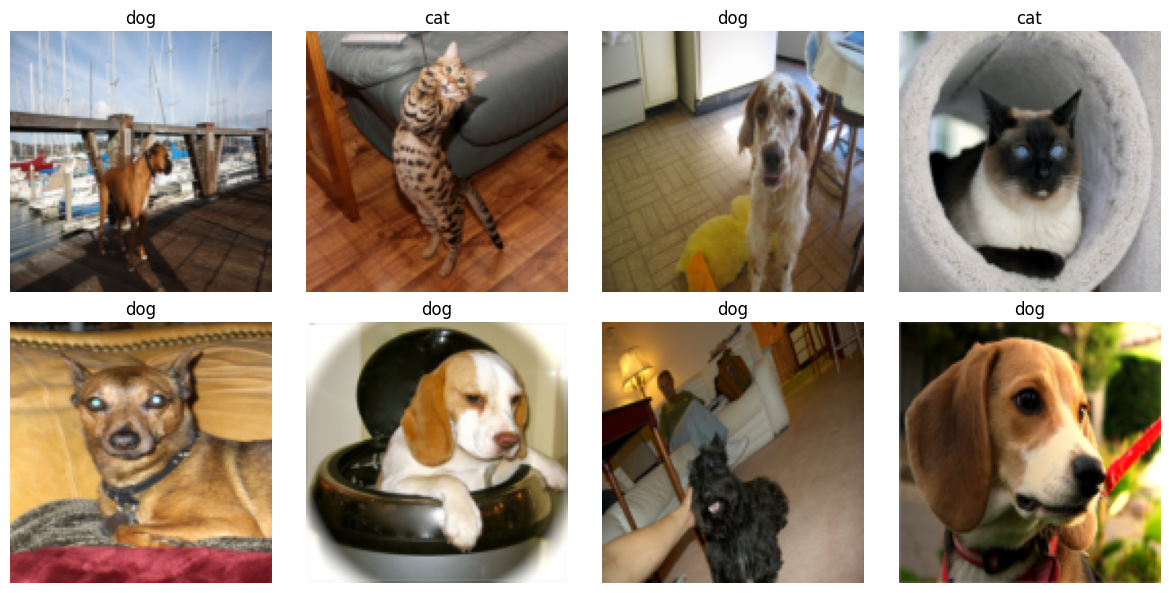

In [7]:
loader = DataLoader(train_ds, batch_size=8, shuffle=True)
x_batch, y_batch = next(iter(loader))
display_examples(x_batch, y_batch)

## Create the model using MobileNetV2

**Global Average Pooling vs Global Max Pooling.** For transfer learning where we're replacing the classification head, global average pooling provides a *summary* of every channel's activations across the whole feature map, which tends to be more stable for downstream classifiers than max pooling.  MobileNetV2 already ends in a `nn.AdaptiveAvgPool2d(1)`, so we don't need to add one.

**`weights = MobileNet_V2_Weights.IMAGENET1K_V2`** loads weights pretrained on ImageNet — this is what enables the transfer.

In [8]:
def build_model():
    weights = MobileNet_V2_Weights.IMAGENET1K_V2
    mnet = mobilenet_v2(weights=weights)
    # Freeze the backbone
    for p in mnet.features.parameters():
        p.requires_grad = False
    # Replace the classifier (the original is for 1000 ImageNet classes)
    in_features = mnet.classifier[-1].in_features  # 1280 for MobileNetV2
    mnet.classifier = nn.Sequential(
        nn.Dropout(0.5),
        nn.Linear(in_features, 1),   # 1 logit (we'll use BCEWithLogitsLoss)
    )
    return mnet.to(device)

model = build_model()
print(model)

Downloading: "https://download.pytorch.org/models/mobilenet_v2-7ebf99e0.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-7ebf99e0.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 80.2MB/s]


MobileNetV2(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU6(inplace=True)
    )
    (1): InvertedResidual(
      (conv): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
          (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (2): ReLU6(inplace=True)
        )
        (1): Conv2d(32, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (2): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
    )
    (2): InvertedResidual(
      (conv): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(16, 96, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (1): BatchNorm2d(96, eps=

In [9]:
# Count trainable vs frozen parameters
n_trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
n_total     = sum(p.numel() for p in model.parameters())
print(f'trainable: {n_trainable:,}  /  total: {n_total:,}')

trainable: 1,281  /  total: 2,225,153


## Model training

In [10]:
batch_size = 32
train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True,  num_workers=2)
test_loader  = DataLoader(test_ds,  batch_size=batch_size, shuffle=False, num_workers=2)
print('train batches:', len(train_loader))
print('test  batches:', len(test_loader))

train batches: 115
test  batches: 115


In [11]:
def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    # Backbone is frozen but we still want eval-mode BN/Dropout for it.
    model.features.eval()
    total_loss = 0.0
    total_correct = 0
    total = 0
    for x, y in loader:
        x = x.to(device)
        y = y.float().unsqueeze(1).to(device)
        optimizer.zero_grad()
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()
        total_loss   += loss.item() * x.size(0)
        preds        = (torch.sigmoid(logits) > 0.5).float()
        total_correct += (preds == y).sum().item()
        total        += x.size(0)
    return total_loss / total, total_correct / total

@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    total_loss, total_correct, total = 0.0, 0, 0
    for x, y in loader:
        x = x.to(device)
        y = y.float().unsqueeze(1).to(device)
        logits = model(x)
        loss = criterion(logits, y)
        total_loss   += loss.item() * x.size(0)
        preds        = (torch.sigmoid(logits) > 0.5).float()
        total_correct += (preds == y).sum().item()
        total        += x.size(0)
    return total_loss / total, total_correct / total

In [12]:
# Quick one-epoch sanity check.
model = build_model()
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-3)

tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, criterion)
va_loss, va_acc = evaluate(model, test_loader, criterion)
print(f'after 1 epoch:  train_loss={tr_loss:.4f}  train_acc={tr_acc:.3f}  '
      f'val_loss={va_loss:.4f}  val_acc={va_acc:.3f}')

after 1 epoch:  train_loss=0.2149  train_acc=0.919  val_loss=0.1113  val_acc=0.961


**Why is validation accuracy sometimes better than training accuracy?**  Dropout is active during training but disabled during evaluation, so the full network capacity is used at validation time.  Also, on the first epoch the loss/accuracy is averaged over a model that is *still learning*, while validation is measured with the model at the end of the epoch.

### Full training with early stopping

In [13]:
def fit(model, train_loader, val_loader, epochs=50, patience=5, lr=1e-3):
    criterion = nn.BCEWithLogitsLoss()
    optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=lr)
    history = {'loss': [], 'accuracy': [], 'val_loss': [], 'val_accuracy': []}
    best_val_loss = float('inf')
    best_state = None
    stale = 0
    for epoch in range(epochs):
        tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, criterion)
        va_loss, va_acc = evaluate(model, val_loader, criterion)
        history['loss'].append(tr_loss);     history['accuracy'].append(tr_acc)
        history['val_loss'].append(va_loss); history['val_accuracy'].append(va_acc)
        print(f'epoch {epoch+1:2d}  tr_loss={tr_loss:.4f} tr_acc={tr_acc:.3f}  '
              f'va_loss={va_loss:.4f} va_acc={va_acc:.3f}')
        if va_loss < best_val_loss:
            best_val_loss = va_loss
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            stale = 0
        else:
            stale += 1
            if stale >= patience:
                print(f'early stopping at epoch {epoch+1}')
                break
    if best_state is not None:
        model.load_state_dict(best_state)
    return history

In [14]:
model = build_model()
history = fit(model, train_loader, test_loader, epochs=50, patience=5, lr=1e-3)

epoch  1  tr_loss=0.2008 tr_acc=0.932  va_loss=0.1072 va_acc=0.967
epoch  2  tr_loss=0.1057 tr_acc=0.962  va_loss=0.0925 va_acc=0.966
epoch  3  tr_loss=0.0895 tr_acc=0.967  va_loss=0.0812 va_acc=0.972
epoch  4  tr_loss=0.0880 tr_acc=0.968  va_loss=0.0779 va_acc=0.975
epoch  5  tr_loss=0.0776 tr_acc=0.971  va_loss=0.0755 va_acc=0.974
epoch  6  tr_loss=0.0726 tr_acc=0.973  va_loss=0.0729 va_acc=0.973
epoch  7  tr_loss=0.0660 tr_acc=0.976  va_loss=0.0740 va_acc=0.973
epoch  8  tr_loss=0.0662 tr_acc=0.975  va_loss=0.0734 va_acc=0.973
epoch  9  tr_loss=0.0664 tr_acc=0.977  va_loss=0.0748 va_acc=0.972
epoch 10  tr_loss=0.0685 tr_acc=0.975  va_loss=0.0723 va_acc=0.974
epoch 11  tr_loss=0.0590 tr_acc=0.978  va_loss=0.0711 va_acc=0.974
epoch 12  tr_loss=0.0623 tr_acc=0.977  va_loss=0.0702 va_acc=0.974
epoch 13  tr_loss=0.0545 tr_acc=0.979  va_loss=0.0752 va_acc=0.974
epoch 14  tr_loss=0.0588 tr_acc=0.980  va_loss=0.0734 va_acc=0.972
epoch 15  tr_loss=0.0547 tr_acc=0.979  va_loss=0.0706 va_acc=0

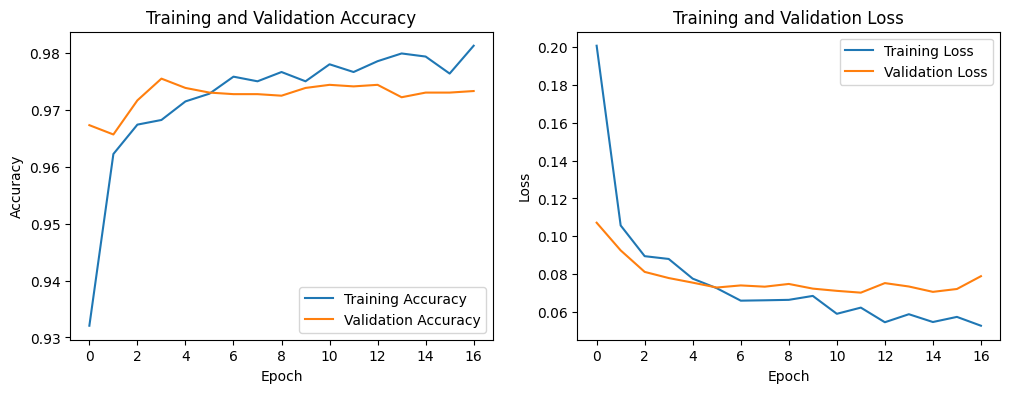

In [15]:
# Plot training history
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history['accuracy'], label='Training Accuracy')
plt.plot(history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch'); plt.ylabel('Accuracy'); plt.legend()
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(history['loss'], label='Training Loss')
plt.plot(history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.legend()
plt.title('Training and Validation Loss')
plt.show()

## Predictions

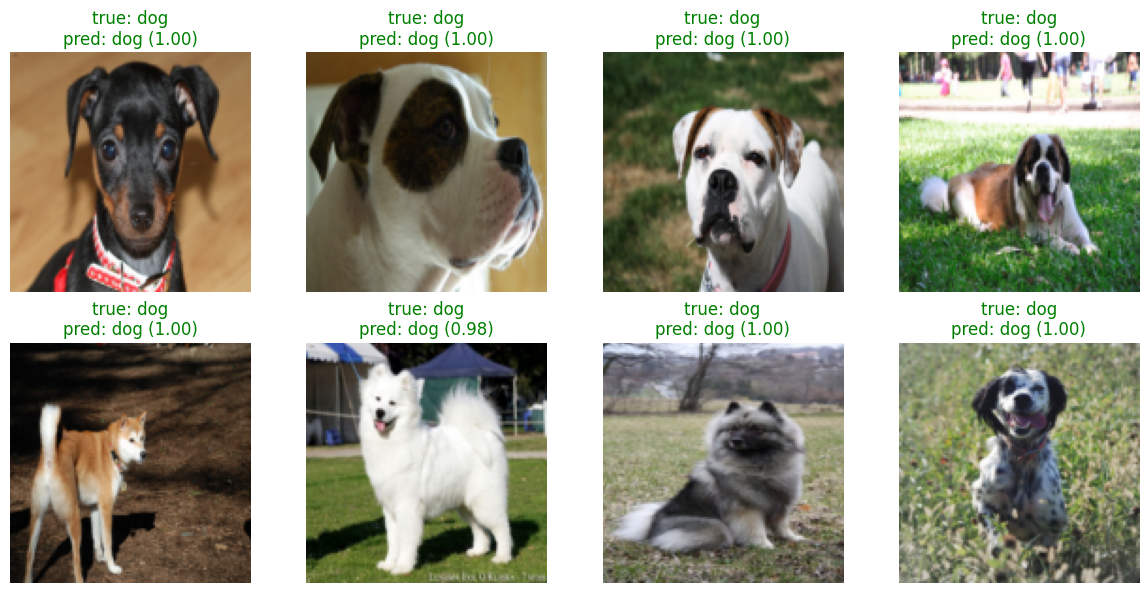

In [16]:
model.eval()
x_batch, y_batch = next(iter(DataLoader(test_ds, batch_size=8, shuffle=True)))
with torch.no_grad():
    probs = torch.sigmoid(model(x_batch.to(device))).cpu().squeeze(1).numpy()
display_examples(x_batch, y_batch, preds=probs)

Prediction: cat  (P(dog) = 0.0016)


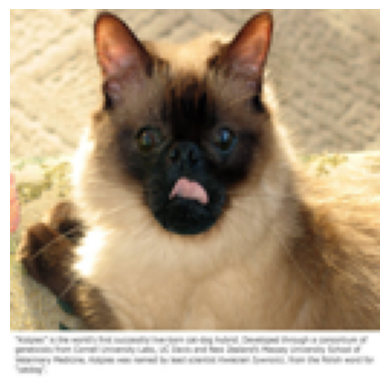

In [17]:
# Predict on an image from a URL
def predict_image_from_url(image_url, model, target_size=(128, 128)):
    """Download an image, preprocess it, predict, and return the PIL image."""
    with urllib.request.urlopen(image_url) as resp:
        raw = resp.read()
    img = Image.open(BytesIO(raw)).convert('RGB').resize(target_size)
    x = preprocess_128(img).unsqueeze(0).to(device)
    model.eval()
    with torch.no_grad():
        prob = torch.sigmoid(model(x)).item()
    predicted_class = index_to_class[int(round(prob))]
    print(f'Prediction: {predicted_class}  (P(dog) = {prob:.4f})')
    return img

# The world's first cat-dog hybrid
url = 'https://assets.atlasobscura.com/article_images/800x/17686/image.jpg'
img = predict_image_from_url(url, model)
plt.imshow(img); plt.axis('off'); plt.show()

## Test data variations: vertical flip

What happens to the model's predictions when we feed it upside-down images?  If the backbone never saw upside-down cats and dogs during pretraining, accuracy should drop.  If that's the case, you can then retrain with a random vertical-flip augmentation and see whether robustness improves.

predictions on FLIPPED test images:


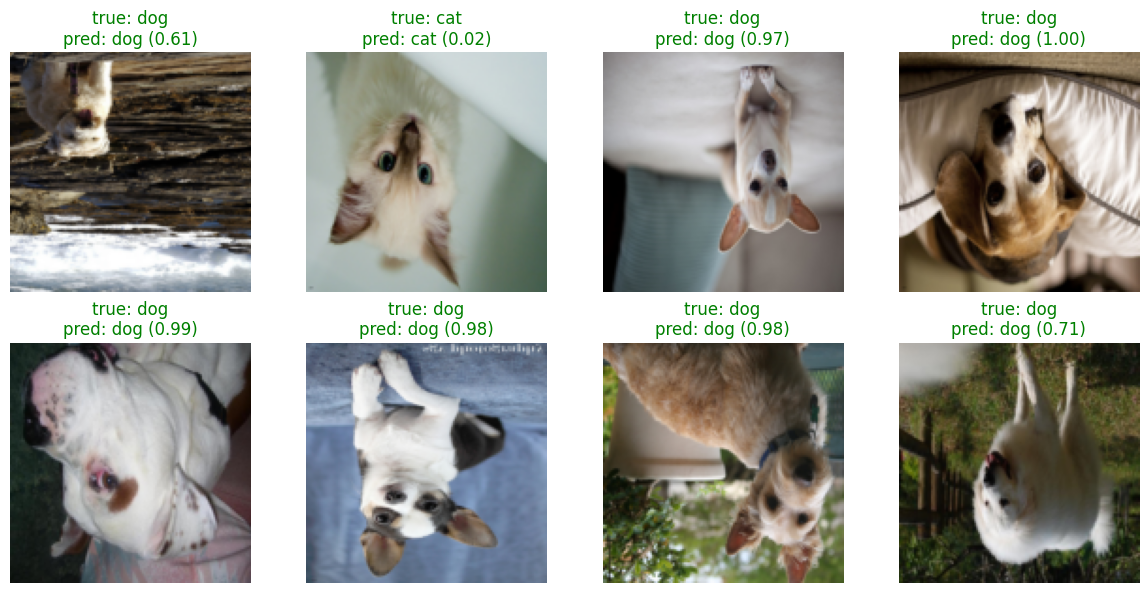

In [19]:
# Re-use the PetsDataset's built-in flip support -- no extra wrapper needed.
flipped_test  = PetsDataset(test_annot, transform=preprocess_128, flip=True)
flipped_loader = DataLoader(flipped_test, batch_size=8, shuffle=True)
x_batch, y_batch = next(iter(flipped_loader))
with torch.no_grad():
    probs = torch.sigmoid(model(x_batch.to(device))).cpu().squeeze(1).numpy()
print('predictions on FLIPPED test images:')
display_examples(x_batch, y_batch, preds=probs)

predictions on NORMAL test images:


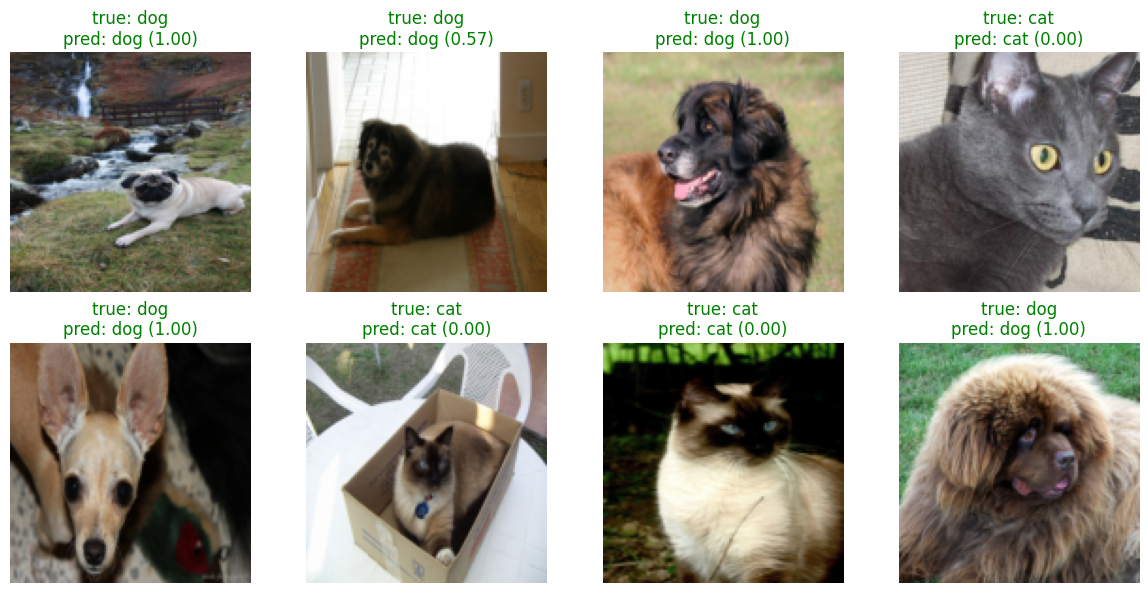

In [20]:
# For comparison: same dataset, NOT flipped.
unflipped_test = PetsDataset(test_annot, transform=preprocess_128, flip=False)
unflipped_loader = DataLoader(unflipped_test, batch_size=8, shuffle=True)
x_batch, y_batch = next(iter(unflipped_loader))
with torch.no_grad():
    probs = torch.sigmoid(model(x_batch.to(device))).cpu().squeeze(1).numpy()
print('predictions on NORMAL test images:')
display_examples(x_batch, y_batch, preds=probs)